## 04 Robustness

Review the selected robustness outputs and summarize

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "reports").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

tables_dir = PROJECT_ROOT / "reports" / "selected_tables"
figures_dir = PROJECT_ROOT / "reports" / "figures"

### Model Summary

In [2]:
pd.read_csv(tables_dir / "model_metrics.csv")

,model,sample,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,rule_based,test,0.426351,0.371301,0.368871,0.425315
1,logistic_regression,test,0.463439,0.375883,0.363306,0.439440
2,xgboost,test,0.474027,0.377400,0.356192,0.442166


### Order-Size Effects

Execution behavior changes when child orders become large relative to displayed depth.

In [3]:
depth_summary = pd.read_csv(tables_dir / "depth_walk_size_stress_summary.csv")
depth_summary[["target_qty", "twap_mean_slippage_bps", "proxy_mean_slippage_bps", "twap_mean_fill_rate", "proxy_mean_fill_rate"]]

,target_qty,twap_mean_slippage_bps,proxy_mean_slippage_bps,twap_mean_fill_rate,proxy_mean_fill_rate
0,10.0,3.037172,3.062917,1.000000,1.000000
1,50.0,3.037679,3.062917,1.000000,1.000000
2,100.0,3.038823,3.062917,1.000000,1.000000
3,500.0,3.042869,3.064215,1.000000,1.000000
4,1000.0,3.043879,3.064662,1.000000,1.000000
5,5000.0,3.052968,3.066443,0.999895,1.000000
6,10000.0,3.060956,3.068183,0.999611,1.000000
7,50000.0,3.052945,3.077287,0.995828,1.000000
8,100000.0,3.077113,3.086806,0.992629,1.000000
9,250000.0,3.126448,3.105272,0.982246,1.000000


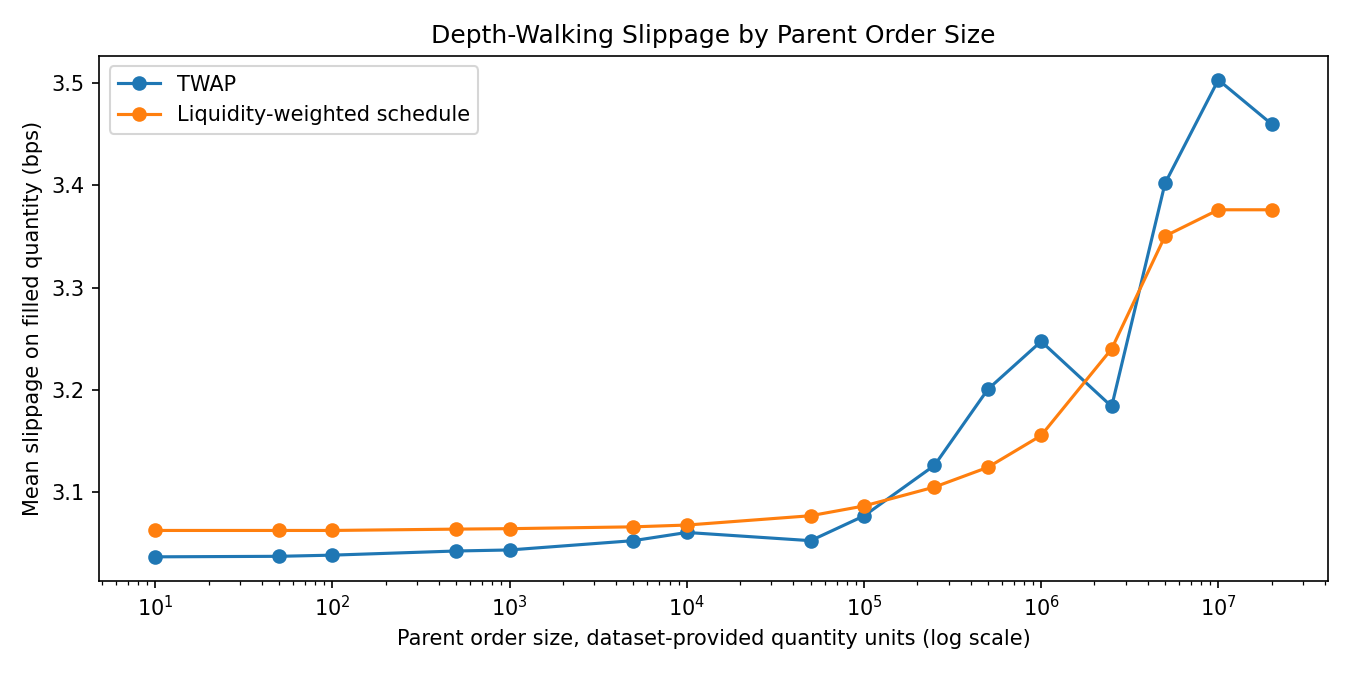

In [4]:
display(Image(filename=str(figures_dir / "depth_stress_slippage_by_size.png")))

### Signal-Adjusted Execution

In [5]:
pd.read_csv(tables_dir / "signal_adjusted_execution_summary.csv")

,strategy,mean_slippage_bps,median_slippage_bps,mean_execution_cost,median_execution_cost,mean_fill_rate,mean_avg_levels_used,mean_pct_walked_beyond_top,mean_requested_qty,mean_executed_qty,mean_unfilled_qty,mean_order_size_to_visible_depth_ratio,lowest_slippage_count,lowest_slippage_share
0,liquidity_weighted_schedule,1.506214,-5.523644,1.155226e+06,-9.685817e+06,0.746411,0.998333,0.0,500000.0,373205.655755,126794.344245,2.953203,5,0.25
1,obi_adjusted_twap,0.311081,-6.318706,-2.613414e+06,-1.041987e+07,0.641661,0.998333,0.0,500000.0,320830.291484,179169.708516,2.953203,13,0.65
2,twap,0.842235,-6.191396,-2.346430e+05,-1.059237e+07,0.684977,0.998333,0.0,500000.0,342488.329053,157511.670947,2.953203,2,0.10


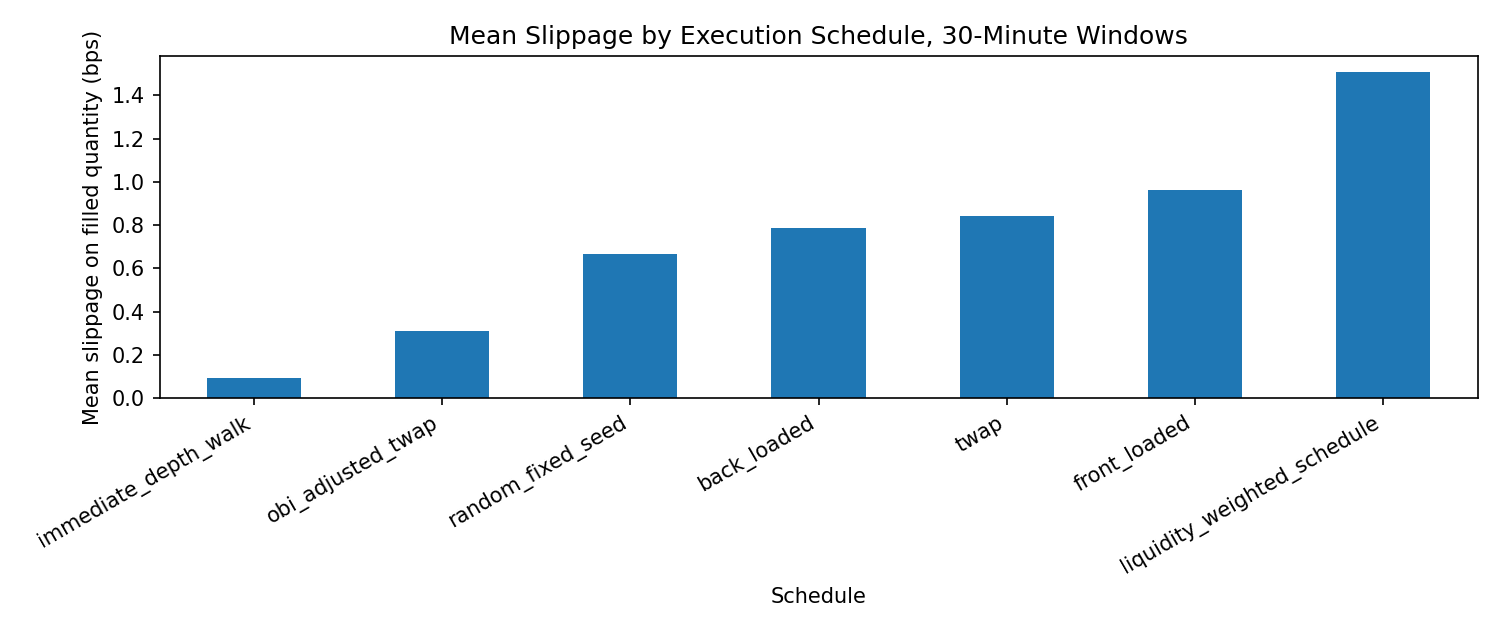

In [6]:
display(Image(filename=str(figures_dir / "execution_schedule_slippage.png")))

### Regime Filter Robustness

Negative OBI-minus-TWAP slippage means the OBI-adjusted schedule improved versus static TWAP.

In [7]:
pd.read_csv(tables_dir / "signal_robustness_by_filter.csv")

,robustness_dimension,setting,mean_obi_minus_twap_slippage_bps,median_obi_minus_twap_slippage_bps,share_obi_beats_twap,mean_obi_fill_rate
0,regime_filter,False,0.608792,0.224406,0.3,0.580211
1,regime_filter,True,0.041996,-0.072297,0.5,0.631186


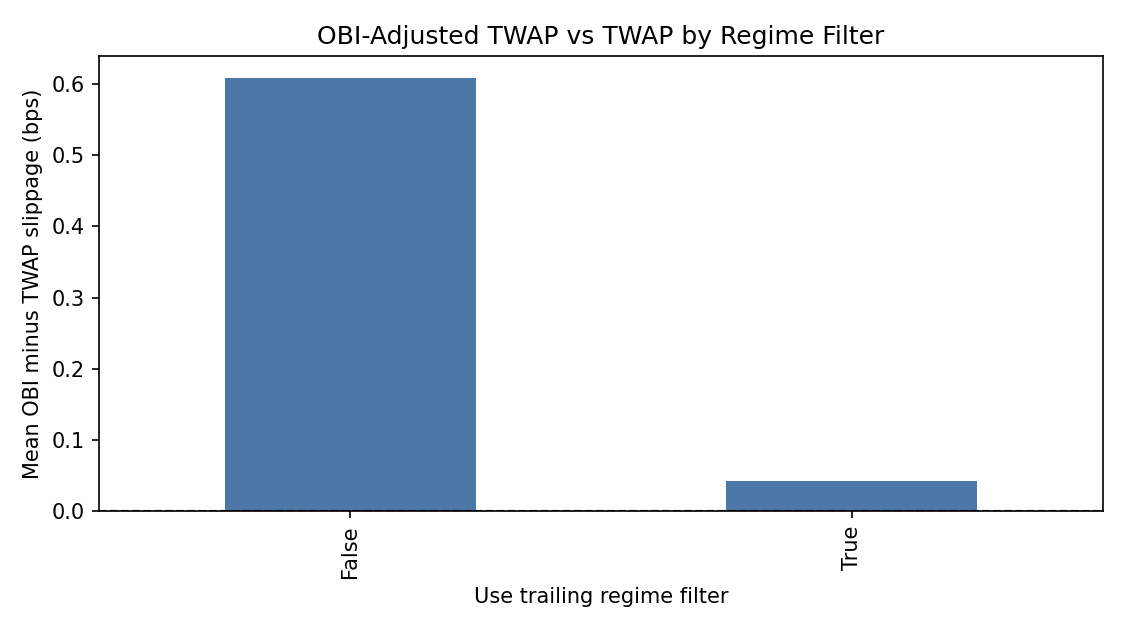

In [8]:
display(Image(filename=str(figures_dir / "signal_robustness_by_filter.png")))